### PCA
- Goal : Implement PCA from scratch using Numpy
- Will implement it on the Diabetes data from sklearn

In [21]:
import numpy as np

from sklearn.datasets import load_diabetes

diabetes = load_diabetes() #Part of sklearn library
X = diabetes.data

In [22]:
def standardization(X): #THIS DATA IS ALREADY SCALED, WE DONT HAVE TO CALL THIS EXPLICITLY
    mean = np.mean(X, axis=0) #Compute mean and std deviation feature wise
    std = np.std(X, axis=0)

    return (X - mean) / std

In [23]:
def constructCovMatx(X):
    X = X - np.mean(X, axis=0) #Mean centering along features
    return (X.T @ X) / (X.shape[0] - 1)

In [24]:
def getPCA(cov):
    eigVals, eigVecs = np.linalg.eigh(cov)
    return eigVals, eigVecs

In [25]:
def getOptimal(srtdEigVals,srtdEigVecs,threshold=0.95):

    expVar = srtdEigVals / np.sum(srtdEigVals) #Explained variance
    cmltvVar = np.cumsum(expVar) #CUmulative variance

    k = np.argmax(cmltvVar >= threshold) + 1
    
    optimalVecs = srtdEigVecs[:, :k]

    return (k, optimalVecs, expVar, cmltvVar)

In [26]:
def Transform(X, optimalVecs):
    xCentrd = X - np.mean(X, axis=0)

    return xCentrd @ optimalVecs

In [12]:
cov = constructCovMatx(X)
eigVals, eigVecs = getPCA(cov)

In [13]:
'''
linalg.eig doesnt guarantee sorted return, so will have to do it manually
'''
idx = np.argsort(eigVals)[::-1] #THIS WILL RETURN SORTED INDEXES, [::-1] FOR REVERSING
srtdEigVals = eigVals[idx]
srtdEigVecs = eigVecs[:, idx] 

In [14]:
k, optimalVecs, expVar, cmltvVar = getOptimal(srtdEigVals, srtdEigVecs, threshold=0.95)

In [15]:
xReduced = Transform(X, optimalVecs)

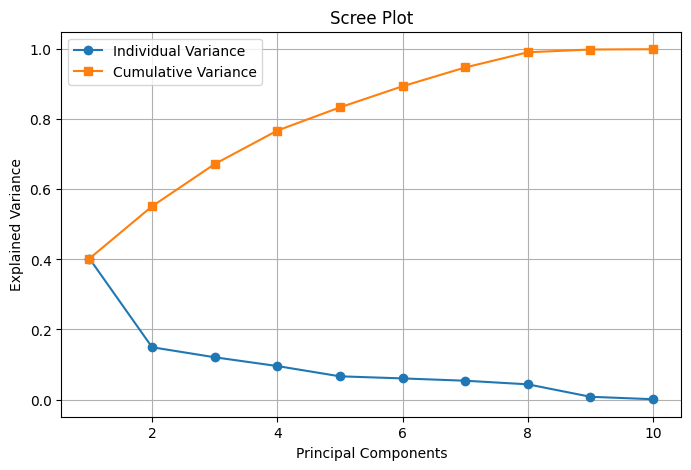

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(expVar)+1),
    expVar,
    marker='o',
    label="Individual Variance"
)

plt.plot(
    range(1, len(cmltvVar)+1),
    cmltvVar,
    marker='s',
    label="Cumulative Variance"
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.grid(True)
plt.legend()

plt.show()

In [20]:
print("PCA SUMMARY")
print("-"*40)

print(f"Original Features : {X.shape[1]}")
print(f"Selected PCs      : {k}")
print(f"Removed Features  : {X.shape[1]-k}")
print(f"Variance Retained : {cmltvVar[k-1]*100:.2f}%")
print(f"Reduced Shape     : {xReduced.shape}")

PCA SUMMARY
----------------------------------------
Original Features : 10
Selected PCs      : 8
Removed Features  : 2
Variance Retained : 99.13%
Reduced Shape     : (442, 8)
